# Entropy-informed feedback: executable research notebook

Prepared for Ryan Hopkins · 7 September 2026

This self-contained notebook reruns a synthetic individual and displays the recorded 1,296-run benchmark. The [interactive brain lab](https://bbci-entropic-research-lab.ryan-hopkins.chatgpt.site) provides a 3D browser interface.

**Research scope:** no patient data, diagnosis, stimulation dose or demonstrated therapy. A lower tracking error is an engineering result, not a clinical benefit.

Install the accompanying `requirements.txt` in Python 3.12, or install NumPy, Numba, SciPy, Matplotlib, JupyterLab and ipykernel. The full benchmark is reproduced using `python run_experiments.py` in the research package.

## 1. Executable model

The following collapsed cell contains the complete model. It is the package implementation with notebook compilation caching disabled. See Wilson and Cowan (1972), https://doi.org/10.1016/S0006-3495(72)86068-5, and Bandt and Pompe (2002), https://doi.org/10.1103/PhysRevLett.88.174102. All parameter choices in this benchmark are synthetic.

In [1]:
"""Reproducible Wilson-Cowan-type neural-mass benchmark.

All current, gain, coupling and controller amplitudes are dimensionless.
Regions and connections are synthetic. No diagnostic or treatment inference.
Reference: Wilson & Cowan (1972), doi:10.1016/S0006-3495(72)86068-5.
"""
from dataclasses import dataclass
import math
import numpy as np
from numba import njit

ARMS = ('sham', 'fixed', 'rate', 'entropy', 'combined', 'yoked')

@dataclass
class Person:
    index: int = 0
    n: int = 16
    def __post_init__(self):
        r = np.random.default_rng(4100 + self.index)
        self.gain = float(r.uniform(1.25, 1.75))
        self.coupling = float(r.uniform(1.4, 2.6))
        self.drive = float(r.uniform(.55, 1.05))
        self.disturbance = float(r.choice([-1, 1]) * r.uniform(.35, .8))
        self.w_ee = r.uniform(2.5, 4.5, self.n)
        self.w_ei = r.uniform(9, 11, self.n)
        # Two hemispheres, four modules; no autism label is assigned.
        i,j = np.indices((self.n,self.n))
        w = .15 + .6*((i%8)//2 == (j%8)//2) + .3*(i//8 == j//8)
        w = w*r.lognormal(0,.3,w.shape)
        np.fill_diagonal(w,0)
        self.W = w/w.sum(axis=1,keepdims=True)
        # Broad illustrative actuator, stronger in association populations.
        self.field = np.array([.35,.35,.65,.65,1,1,.75,.75]*2)

@njit(cache=False)
def _rng(state):
    state = (1664525*state + 1013904223) & 4294967295
    return state, (state+.5)/4294967296

@njit(cache=False)
def _normal(state):
    state,u = _rng(state); state,v = _rng(state)
    return state, math.sqrt(-2*math.log(u))*math.cos(2*math.pi*v)

@njit(cache=False)
def _pe(x, lag=2):
    counts=np.zeros(6); total=len(x)-2*lag
    if total<1: return 0.
    for t in range(total):
        a,b,c=x[t],x[t+lag],x[t+2*lag]
        # Stable tie order: a precedes b precedes c.
        if a<=b:
            k=0 if b<=c else (1 if a<=c else 4)
        else:
            k=2 if a<=c else (3 if b<=c else 5)
        counts[k]+=1
    h=0.
    for k in range(6):
        if counts[k]>0:
            p=counts[k]/total; h-=p*math.log(p)
    return h/math.log(6.)

def permutation_entropy(x, lag=2):
    return float(_pe(np.asarray(x,dtype=float),lag))

@njit(cache=False)
def _run(W0,wee,wei,field,gain,coupling,drive,disturbance,seed,arm,
         dt,duration,target_r,target_h,h_slope,fixed,measurement_noise,
         artifact,delay,plasticity,replay,stressed,amplitude,freeze_after,dynamic_noise):
    n=len(wee); steps=int(round(duration/dt)); stride=int(round(.01/dt))
    nout=steps//stride; window=100; out=np.zeros((nout,n))
    observed=np.zeros(nout); labels=np.zeros(nout); us=np.zeros(nout)
    hs=np.zeros(nout); drift=np.zeros(nout); rs=np.zeros(nout)
    E=np.full(n,.1); I=np.full(n,.1); noise=np.zeros(n); avg=np.full(n,.1)
    W=W0.copy(); u=0.; h=0.; state=int(seed); m=0.; cov=np.zeros((n,n))
    ew=np.zeros(n); iw=np.zeros(n); label=1.; q=0
    cap_events=0; clip_events=0
    # Delay is an integer number of 1-second update windows.
    for t in range(steps):
        sec=t*dt
        if t % int(round(.5/dt)) == 0:
            state,z=_rng(state); label=1. if z>.5 else -1.
        perturb=0.
        if stressed and sec>=15 and sec<45:
            perturb=disturbance*(1. if sec<30 else -.6)
        for i in range(n):
            state,z=_normal(state)
            noise[i] += -dt/.15*noise[i] + dynamic_noise*math.sqrt(2*dt/.15)*z
        # Euler update, simultaneous E/I state transition.
        for i in range(n):
            network=0.
            for j in range(n): network+=W[i,j]*E[j]
            task=.6*label if i%8<2 else 0.
            a=gain*(wee[i]*E[i]-wei[i]*I[i]+coupling*network+drive+task+perturb+field[i]*u+noise[i]-2.5)
            b=gain*(10*E[i]-2*I[i]-3.)
            se=1/(1+math.exp(-max(-50.,min(50.,a))))
            si=1/(1+math.exp(-max(-50.,min(50.,b))))
            ew[i]=E[i]+dt/.04*(-E[i]+se)
            iw[i]=I[i]+dt/.08*(-I[i]+si)
        for i in range(n):
            E[i]=ew[i]; I[i]=iw[i]
            avg[i]+=dt/2*(E[i]-avg[i])
        if plasticity>0:
            for i in range(n):
                for j in range(n):
                    if i!=j:
                        learn=plasticity*(E[i]-avg[i])*(E[j]-avg[j]) if sec<freeze_after else 0.
                        change=learn-(W[i,j]-W0[i,j])/20
                        raw=W[i,j]+dt*change
                        W[i,j]=max(.25*W0[i,j],min(2*W0[i,j],raw))
        if (t+1)%stride==0:
            m=0.; dw=0.; denom=0.
            for i in range(n):
                out[q,i]=E[i]; m+=E[i]/n
                for j in range(n):
                    dw+=(W[i,j]-W0[i,j])**2; denom+=W0[i,j]**2
            # Observe population mean, not a validated EEG forward model.
            state,z=_normal(state)
            observed[q]=m+measurement_noise*z+artifact*u*math.sin(2*math.pi*37*sec)
            labels[q]=label; us[q]=u; rs[q]=m; drift[q]=math.sqrt(dw/denom)
            hs[q]=h
            if (q+1)%window==0:
                end=q+1-delay*window
                if end>=window:
                    h=_pe(observed[end-window:end],2)
                    rm=np.mean(observed[end-window:end])
                    er=target_r-rm; eh=target_h-h
                    # A calibration derivative with a dead zone, not entropy maximization.
                    du=0. if abs(h_slope)<.01 else max(-.35,min(.35,eh/h_slope))
                    rate=4*er
                    proposal=0.
                    if arm==1: proposal=fixed
                    elif arm==2: proposal=rate
                    elif arm==3: proposal=.5*u+.5*du
                    elif arm==4: proposal=rate+.3*du
                    elif arm==5:
                        idx=min(int(sec),len(replay)-1); proposal=replay[idx]
                    if sec<10 or sec>=45: proposal=0.
                    if abs(proposal)>amplitude: cap_events+=1
                    # Slew and amplitude limits are numerical constraints only.
                    delta=max(-.15,min(.15,proposal-u))
                    u=max(-amplitude,min(amplitude,u+delta))
            q+=1
    return out,observed,labels,us,hs,drift,rs,cap_events

def simulate(person=None, arm='sham', seed=100, duration=60., dt=.002,
             calibration=None, measurement_noise=.001, artifact=0., delay=0,
             plasticity=.0, replay=None, stressed=True, amplitude=.6,
             fixed_override=None, freeze_after=45., dynamic_noise=.04):
    p=person or Person()
    if dt<=0 or abs(round(.01/dt)*dt-.01)>1e-9 or dt>.01:
        raise ValueError('dt must evenly divide 0.01 and be <=0.01 s')
    c=calibration or {'rate':.2,'entropy':.8,'slope':0.,'fixed':0.}
    if delay<0 or int(delay)!=delay: raise ValueError('delay must be an integer >=0')
    vals=_run(p.W,p.w_ee,p.w_ei,p.field,p.gain,p.coupling,p.drive,p.disturbance,
       seed,ARMS.index(arm),dt,duration,c['rate'],c['entropy'],c['slope'],
       c['fixed'] if fixed_override is None else fixed_override,measurement_noise,
       artifact,int(delay),plasticity,np.zeros(61) if replay is None else replay,
       stressed,amplitude,freeze_after,dynamic_noise)
    return dict(zip(('E','observed','label','u','entropy_online','drift','rate','cap_events'),vals))

def calibrate(p, seed=710):
    # Independent reference session; no outcome labels from evaluation are used.
    baseline=simulate(p,seed=seed,stressed=False,measurement_noise=.001)
    selected=slice(1000,4500)
    rate=float(baseline['rate'][selected].mean())
    hs=[permutation_entropy(baseline['observed'][k:k+100]) for k in range(1000,4401,100)]
    entropy=float(np.mean(hs))
    c={'rate':rate,'entropy':entropy,'slope':0.,'fixed':0.}
    plus=simulate(p,'fixed',seed=seed,stressed=False,calibration=c,fixed_override=.2)
    minus=simulate(p,'fixed',seed=seed,stressed=False,calibration=c,fixed_override=-.2)
    hp=np.mean([permutation_entropy(plus['observed'][k:k+100]) for k in range(1500,4401,100)])
    hm=np.mean([permutation_entropy(minus['observed'][k:k+100]) for k in range(1500,4401,100)])
    c['slope']=float((hp-hm)/.4)
    # Ridge readout from non-input populations, delayed to reflect response latency.
    idx=np.array([i for i in range(p.n) if i%8>=2]); c['readout_indices']=idx.tolist()
    X=baseline['E'][1000:4500,idx]; y=baseline['label'][985:4485]
    center=X.mean(0); scale=X.std(0)+1e-6; Z=(X-center)/scale
    beta=np.linalg.solve(Z.T@Z+10*np.eye(len(idx)),Z.T@y)
    c.update(center=center.tolist(),scale=scale.tolist(),beta=beta.tolist())
    # Open-loop comparator tuned on independent perturbed calibration data.
    scores=[]; candidates=np.linspace(-.6,.6,7)
    for u in candidates:
        rr=simulate(p,'fixed',seed=seed+1,calibration=c,fixed_override=float(u))
        scores.append(evaluate(rr,c)['tracking_mse'])
    c['fixed']=float(candidates[int(np.argmin(scores))])
    c['baseline_accuracy']=evaluate(baseline,c)['accuracy']
    return c

def evaluate(run,c):
    e=run['E']; idx=c['readout_indices']
    z=(e[:,idx]-np.asarray(c['center']))/np.asarray(c['scale'])
    prediction=z@np.asarray(c['beta']); target=np.roll(run['label'],15)
    s=slice(1500,4500); wash=slice(4700,6000)
    err=(prediction-target)**2
    obs=run['observed'][s]
    fft=np.abs(np.fft.rfft(obs-obs.mean()))**2; fft=fft[1:]; prob=fft/(fft.sum()+1e-15)
    spectral=float(-np.sum(prob*np.log(prob+1e-15))/np.log(len(prob)))
    return {'tracking_mse':float(err[s].mean()),
      'accuracy':float(np.mean((prediction[s]>0)==(target[s]>0))),
      'rate_error':float(np.mean((run['rate'][s]-c['rate'])**2)),
      'entropy':float(np.mean([permutation_entropy(obs[k:k+100]) for k in range(0,len(obs)-99,100)])),
      'spectral_entropy':spectral,
      'saturation_fraction':float(np.mean((e[s]<.02)|(e[s]>.98))),
      'control_energy':float(np.mean(run['u'][s]**2)),
      'washout_mse':float(err[wash].mean()),
      'weight_change':float(run['drift'][4499]),
      'washout_weight_change':float(run['drift'][-1]),
      'cap_events':int(run['cap_events'])}


## 2. Choose a synthetic individual and observation conditions

Edit these parameters and run all subsequent cells. The reference is calibrated separately. Increasing noise, adding delay, or changing gain after calibration may undermine the feedback assumption. No parameter is a physical device dose.

In [2]:
individual = 0
seed = 100
measurement_noise = 0.001
extra_delay_seconds = 0
artifact_scale = 0.0
plasticity_rate = 0.0
person = Person(individual)
calibration = calibrate(person, seed=710 + 11*individual)
print({k:round(calibration[k],5) for k in ('rate','entropy','slope','fixed')})

{'rate': 0.10802, 'entropy': 0.95089, 'slope': -0.04334, 'fixed': -0.2}


## 3. Run a six-strategy comparison

The yoked input comes from the next synthetic individual. One-person yoked energy need not equal one-person combined energy; the complete cyclic benchmark matches energy in aggregate.

In [3]:
runs = {}
options = dict(measurement_noise=measurement_noise, delay=extra_delay_seconds, artifact=artifact_scale, plasticity=plasticity_rate)
for arm in ARMS[:-1]:
    runs[arm] = simulate(person, arm, seed=seed, calibration=calibration, **options)
donor = Person((individual+1)%24)
donor_cal = calibrate(donor, seed=710 + 11*donor.index)
donor_run = simulate(donor, 'combined', seed=seed, calibration=donor_cal, **options)
replay = np.array([donor_run['u'][min((k+1)*100,5999)] for k in range(60)])
runs['yoked'] = simulate(person,'yoked',seed=seed,calibration=calibration,replay=replay,**options)
metrics = {a:evaluate(r,calibration) for a,r in runs.items()}
print(f"{'Strategy':<12} {'Tracking MSE':>13} {'Accuracy':>10} {'Energy':>10}")
for a,m in metrics.items():
    print(f"{a:<12} {m['tracking_mse']:13.3f} {m['accuracy']:10.3%} {m['control_energy']:10.4f}")

Strategy      Tracking MSE   Accuracy     Energy
sham                43.300    42.100%     0.0000
fixed               41.938    42.100%     0.0400
rate                32.989    42.133%     0.0284
entropy             31.149    42.133%     0.0742
combined            29.862    42.133%     0.0546
yoked               30.922    42.133%     0.0427


## 4. Inspect the same run from three perspectives

Entropy, neural activity and applied input answer different questions. The input phases are model perturbations, not diagnosed clinical states.

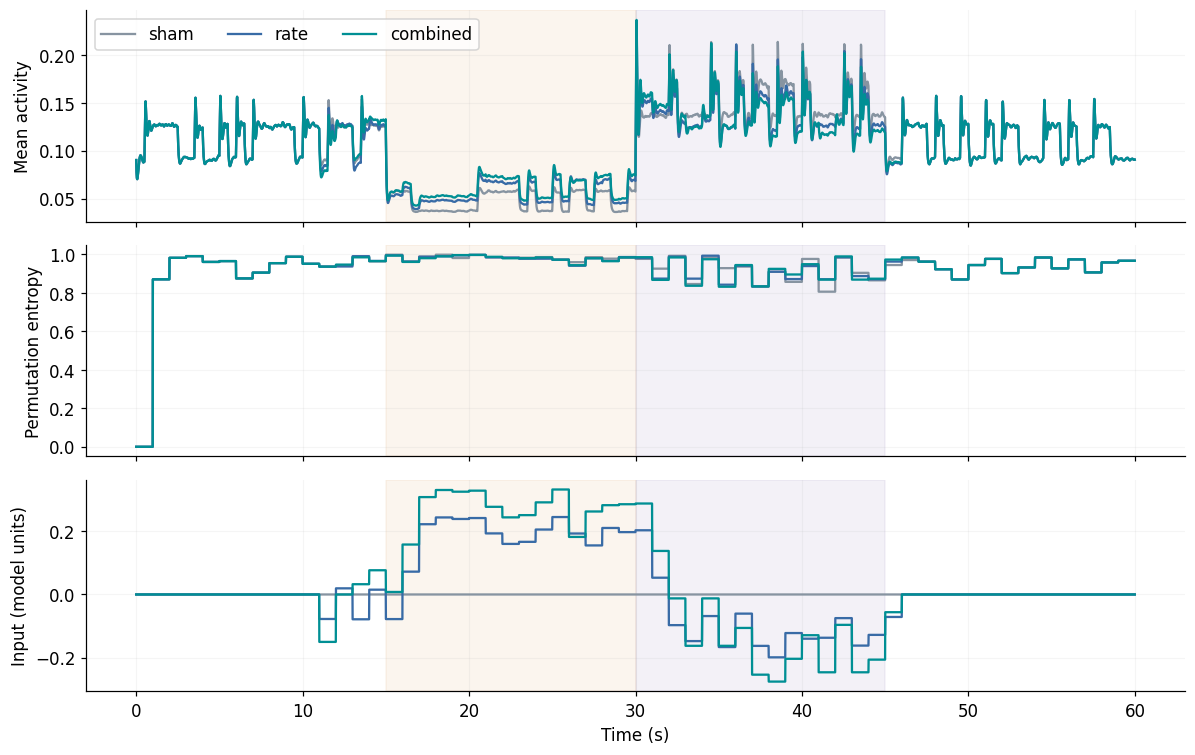

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
fig,axes=plt.subplots(3,1,figsize=(11,7),sharex=True)
time=np.arange(6000)/100
colors={'sham':'#8794a1','rate':'#386ba6','combined':'#008f94'}
for ax,key,label in zip(axes,['rate','entropy_online','u'],['Mean activity','Permutation entropy','Input (model units)']):
    for a in colors: ax.plot(time,runs[a][key],label=a,color=colors[a],lw=1.5)
    ax.axvspan(15,30,color='#d39147',alpha=.09);ax.axvspan(30,45,color='#806bb0',alpha=.09)
    ax.set_ylabel(label);ax.grid(alpha=.12)
axes[0].legend(ncol=3);axes[-1].set_xlabel('Time (s)');fig.tight_layout();plt.show()

## 5. Recorded complete benchmark

The next cell embeds the aggregate output of the completed 1,296-run Python study, including the source hash. These results are **recorded**, not recomputed by this notebook. Recompute them using the package script. Intervals resample synthetic individuals after averaging seeds.

In [5]:
import json
study = json.loads('{\n  "summary": {\n    "nominal_sham": {\n      "tracking_mse": [\n        124.4061210494757,\n        88.13993991325404,\n        166.07911647081127\n      ],\n      "accuracy": [\n        0.5003981481481481,\n        0.4984952546296296,\n        0.5023473379629629\n      ],\n      "rate_error": [\n        0.0030996563427998975,\n        0.0026081898419394916,\n        0.0036103269851632145\n      ],\n      "entropy": [\n        0.9491391655034233,\n        0.940653548780305,\n        0.9565383459265792\n      ],\n      "spectral_entropy": [\n        0.18721502383412972,\n        0.1765203099522209,\n        0.19836443888190772\n      ],\n      "control_energy": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_mse": [\n        0.6697555612909564,\n        0.6179063185182757,\n        0.7206963458365586\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "nominal_fixed": {\n      "tracking_mse": [\n        69.93952342413728,\n        55.260351579508914,\n        84.80564069261082\n      ],\n      "accuracy": [\n        0.5258148148148148,\n        0.504986111111111,\n        0.5521116898148148\n      ],\n      "rate_error": [\n        0.0024304842266170365,\n        0.0020138228157650174,\n        0.002867227843425259\n      ],\n      "entropy": [\n        0.9610868320094171,\n        0.9555746486064042,\n        0.9660305108231894\n      ],\n      "spectral_entropy": [\n        0.20047341569489266,\n        0.1876452881017762,\n        0.21493730537836495\n      ],\n      "control_energy": [\n        0.19166666666666665,\n        0.1366666666666667,\n        0.2483333333333333\n      ],\n      "washout_mse": [\n        1.7826595974380508,\n        1.3046224421750239,\n        2.3188112159497627\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "nominal_rate": {\n      "tracking_mse": [\n        81.36198666605513,\n        58.98416642429441,\n        106.0971304594472\n      ],\n      "accuracy": [\n        0.5004259259259259,\n        0.4984721064814815,\n        0.502412037037037\n      ],\n      "rate_error": [\n        0.002230233237049707,\n        0.0018915603948317648,\n        0.002584082570360852\n      ],\n      "entropy": [\n        0.9478458057881801,\n        0.9398999958450273,\n        0.9550961517643624\n      ],\n      "spectral_entropy": [\n        0.24175027585432618,\n        0.22935725672087606,\n        0.2547755359982742\n      ],\n      "control_energy": [\n        0.028963947159055814,\n        0.024812134572814976,\n        0.03333954765338888\n      ],\n      "washout_mse": [\n        0.6698171855859897,\n        0.6180166884967996,\n        0.7207528497073751\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "nominal_entropy": {\n      "tracking_mse": [\n        97.7969071349816,\n        64.99442072197074,\n        135.56423476110825\n      ],\n      "accuracy": [\n        0.5008935185185185,\n        0.49873148148148144,\n        0.5034537037037037\n      ],\n      "rate_error": [\n        0.002319657437284937,\n        0.0019811661249581314,\n        0.0026523165591489295\n      ],\n      "entropy": [\n        0.9449815609015317,\n        0.937124046887846,\n        0.9522178781674742\n      ],\n      "spectral_entropy": [\n        0.2460579258348926,\n        0.231016532744175,\n        0.261743290999211\n      ],\n      "control_energy": [\n        0.04800467130073513,\n        0.04082371185966385,\n        0.05435669022347917\n      ],\n      "washout_mse": [\n        0.6743886432117464,\n        0.625502025415913,\n        0.723285748710244\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "nominal_combined": {\n      "tracking_mse": [\n        76.82872938709151,\n        55.09657792693232,\n        100.62782005771774\n      ],\n      "accuracy": [\n        0.5003425925925926,\n        0.4984119212962963,\n        0.5023288194444444\n      ],\n      "rate_error": [\n        0.0020935161506026637,\n        0.0017813689492565206,\n        0.002417275156855605\n      ],\n      "entropy": [\n        0.9463842986984273,\n        0.9381726844361922,\n        0.9538303333563646\n      ],\n      "spectral_entropy": [\n        0.2573092310690797,\n        0.2441428649581446,\n        0.27096844799857583\n      ],\n      "control_energy": [\n        0.04650917719685268,\n        0.03982356522701723,\n        0.05337104812957645\n      ],\n      "washout_mse": [\n        0.6700347799861204,\n        0.6185355391390437,\n        0.7209033366998497\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "nominal_yoked": {\n      "tracking_mse": [\n        126.77449563592836,\n        84.60809331267484,\n        179.10873444652373\n      ],\n      "accuracy": [\n        0.5006111111111111,\n        0.49867129629629625,\n        0.5028055555555555\n      ],\n      "rate_error": [\n        0.003269277189695241,\n        0.0026177983032271367,\n        0.003956243556431703\n      ],\n      "entropy": [\n        0.9420558622551692,\n        0.9326190021037021,\n        0.9506220807307069\n      ],\n      "spectral_entropy": [\n        0.20722290659288534,\n        0.18460504551395493,\n        0.23107560242624428\n      ],\n      "control_energy": [\n        0.04650917719685268,\n        0.03994412588895972,\n        0.05321902493546862\n      ],\n      "washout_mse": [\n        0.672263137585431,\n        0.6227788183810062,\n        0.7224622593614307\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "delay_2s_sham": {\n      "tracking_mse": [\n        124.4061210494757,\n        88.13993991325404,\n        166.07911647081127\n      ],\n      "accuracy": [\n        0.5003981481481481,\n        0.4984952546296296,\n        0.5023473379629629\n      ],\n      "rate_error": [\n        0.0030996563427998975,\n        0.0026081898419394916,\n        0.0036103269851632145\n      ],\n      "entropy": [\n        0.9491391655034233,\n        0.940653548780305,\n        0.9565383459265792\n      ],\n      "spectral_entropy": [\n        0.18721502383412972,\n        0.1765203099522209,\n        0.19836443888190772\n      ],\n      "control_energy": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_mse": [\n        0.6697555612909564,\n        0.6179063185182757,\n        0.7206963458365586\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "delay_2s_rate": {\n      "tracking_mse": [\n        91.32396450575169,\n        65.8272895282563,\n        119.43037212276622\n      ],\n      "accuracy": [\n        0.5003935185185185,\n        0.49843969907407404,\n        0.5023797453703703\n      ],\n      "rate_error": [\n        0.0024314058223133123,\n        0.002059697046469485,\n        0.0028164462569828233\n      ],\n      "entropy": [\n        0.9460079161375855,\n        0.9371012991850846,\n        0.9540411765890835\n      ],\n      "spectral_entropy": [\n        0.23689192648726387,\n        0.22525997802884856,\n        0.24932211804687726\n      ],\n      "control_energy": [\n        0.0302865292149908,\n        0.025984647118332548,\n        0.0347694482784145\n      ],\n      "washout_mse": [\n        0.6704094151127579,\n        0.6186564144486876,\n        0.7215093949843542\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "delay_2s_combined": {\n      "tracking_mse": [\n        90.55129753497916,\n        64.74622708705958,\n        118.43721904444357\n      ],\n      "accuracy": [\n        0.5004583333333333,\n        0.49849976851851846,\n        0.5025371527777778\n      ],\n      "rate_error": [\n        0.002352714102425485,\n        0.0020032273435324223,\n        0.0027160967369301804\n      ],\n      "entropy": [\n        0.9448266408845992,\n        0.9362962802482333,\n        0.9525732182538165\n      ],\n      "spectral_entropy": [\n        0.24795192487088633,\n        0.23600117538663676,\n        0.26101919684467073\n      ],\n      "control_energy": [\n        0.04842879127937106,\n        0.04177128241112487,\n        0.05525960099773261\n      ],\n      "washout_mse": [\n        0.672092881390355,\n        0.6204174202555964,\n        0.7231197439497655\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "sensor_noise_sham": {\n      "tracking_mse": [\n        124.4061210494757,\n        88.13993991325404,\n        166.07911647081127\n      ],\n      "accuracy": [\n        0.5003981481481481,\n        0.4984952546296296,\n        0.5023473379629629\n      ],\n      "rate_error": [\n        0.0030996563427998975,\n        0.0026081898419394916,\n        0.0036103269851632145\n      ],\n      "entropy": [\n        0.9882558227044136,\n        0.9881922281177665,\n        0.9883232571915311\n      ],\n      "spectral_entropy": [\n        0.6283182601797558,\n        0.596839916872956,\n        0.661106614676477\n      ],\n      "control_energy": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_mse": [\n        0.6697555612909564,\n        0.6179063185182757,\n        0.7206963458365586\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "sensor_noise_rate": {\n      "tracking_mse": [\n        81.53098097505487,\n        59.029330070818645,\n        106.3104497004386\n      ],\n      "accuracy": [\n        0.500412037037037,\n        0.49845370370370373,\n        0.5023798611111111\n      ],\n      "rate_error": [\n        0.0022312091012988487,\n        0.0018908283698165999,\n        0.0025858807548313455\n      ],\n      "entropy": [\n        0.9882733871202124,\n        0.9881786276160207,\n        0.9883600500652954\n      ],\n      "spectral_entropy": [\n        0.7065937697832428,\n        0.6789161379010608,\n        0.734679349373682\n      ],\n      "control_energy": [\n        0.029408998165654964,\n        0.025298343086629767,\n        0.033765390875873255\n      ],\n      "washout_mse": [\n        0.670096377047669,\n        0.6183289892901576,\n        0.7210728350682295\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "sensor_noise_combined": {\n      "tracking_mse": [\n        89.8137658866046,\n        64.34325096713134,\n        117.48277669256116\n      ],\n      "accuracy": [\n        0.500412037037037,\n        0.4984719907407407,\n        0.5024399305555557\n      ],\n      "rate_error": [\n        0.002339902705014854,\n        0.001976488862552736,\n        0.002711463732739393\n      ],\n      "entropy": [\n        0.9882850835234182,\n        0.9881755392782019,\n        0.9883952250207265\n      ],\n      "spectral_entropy": [\n        0.7006973248238362,\n        0.6738982904549867,\n        0.7286357182401788\n      ],\n      "control_energy": [\n        0.036028415611258184,\n        0.031527102153457554,\n        0.04104332403778937\n      ],\n      "washout_mse": [\n        0.6698411944460364,\n        0.61872162206195,\n        0.7202430438090663\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "stimulation_artifact_sham": {\n      "tracking_mse": [\n        124.4061210494757,\n        88.13993991325404,\n        166.07911647081127\n      ],\n      "accuracy": [\n        0.5003981481481481,\n        0.4984952546296296,\n        0.5023473379629629\n      ],\n      "rate_error": [\n        0.0030996563427998975,\n        0.0026081898419394916,\n        0.0036103269851632145\n      ],\n      "entropy": [\n        0.9491391655034233,\n        0.940653548780305,\n        0.9565383459265792\n      ],\n      "spectral_entropy": [\n        0.18721502383412972,\n        0.1765203099522209,\n        0.19836443888190772\n      ],\n      "control_energy": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_mse": [\n        0.6697555612909564,\n        0.6179063185182757,\n        0.7206963458365586\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "stimulation_artifact_rate": {\n      "tracking_mse": [\n        81.3619866660552,\n        58.98416642429449,\n        106.09713045944727\n      ],\n      "accuracy": [\n        0.5004259259259259,\n        0.4984721064814815,\n        0.502412037037037\n      ],\n      "rate_error": [\n        0.002230233237049709,\n        0.001891560394831766,\n        0.0025840825703608537\n      ],\n      "entropy": [\n        0.9708987316600064,\n        0.9702752953433149,\n        0.9714605699162114\n      ],\n      "spectral_entropy": [\n        0.313101443559431,\n        0.3020119051656467,\n        0.3251135000181485\n      ],\n      "control_energy": [\n        0.028963947159055845,\n        0.024812134572815003,\n        0.03333954765338892\n      ],\n      "washout_mse": [\n        0.6698171855859897,\n        0.6180166884967996,\n        0.7207528497073751\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "stimulation_artifact_combined": {\n      "tracking_mse": [\n        84.88496945819874,\n        61.17001128252656,\n        110.89240825239156\n      ],\n      "accuracy": [\n        0.5003101851851852,\n        0.4984211805555555,\n        0.5022688657407406\n      ],\n      "rate_error": [\n        0.0022824702779247956,\n        0.0019222726152340053,\n        0.0026526223819134387\n      ],\n      "entropy": [\n        0.9694264719217767,\n        0.9679349949703415,\n        0.9705630063405292\n      ],\n      "spectral_entropy": [\n        0.3234676673676076,\n        0.31266123747194113,\n        0.33524762013088777\n      ],\n      "control_energy": [\n        0.03594944943934584,\n        0.031228166425869806,\n        0.04124844673585197\n      ],\n      "washout_mse": [\n        0.6701320796924174,\n        0.6188071415599228,\n        0.7207821134620709\n      ],\n      "weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_weight_change": [\n        0.0,\n        0.0,\n        0.0\n      ]\n    },\n    "plasticity_sham": {\n      "tracking_mse": [\n        125.44410297431735,\n        88.88142645575056,\n        167.45130946122154\n      ],\n      "accuracy": [\n        0.5003935185185184,\n        0.4984907407407407,\n        0.5023379629629628\n      ],\n      "rate_error": [\n        0.0031321559700420443,\n        0.0026334707615912403,\n        0.003650754630005615\n      ],\n      "entropy": [\n        0.9479774724481778,\n        0.9390153384171049,\n        0.9559208715848158\n      ],\n      "spectral_entropy": [\n        0.1880947138909755,\n        0.17729255923430529,\n        0.19926031154328006\n      ],\n      "control_energy": [\n        0.0,\n        0.0,\n        0.0\n      ],\n      "washout_mse": [\n        0.675129684159477,\n        0.6225689801472949,\n        0.7272327036066608\n      ],\n      "weight_change": [\n        0.026302147414639803,\n        0.0241017213846638,\n        0.028748417515676004\n      ],\n      "washout_weight_change": [\n        0.012423788772061928,\n        0.011384420093375579,\n        0.013579281612078836\n      ]\n    },\n    "plasticity_rate": {\n      "tracking_mse": [\n        81.89053560370172,\n        59.40007605611608,\n        106.78428225300833\n      ],\n      "accuracy": [\n        0.5004074074074074,\n        0.49846747685185183,\n        0.5023842592592592\n      ],\n      "rate_error": [\n        0.002251006122343769,\n        0.001907432345895047,\n        0.0026098559587934968\n      ],\n      "entropy": [\n        0.9466056090767291,\n        0.9380786965400418,\n        0.9542541596423431\n      ],\n      "spectral_entropy": [\n        0.24287187579648062,\n        0.23032913544169792,\n        0.25599705602390965\n      ],\n      "control_energy": [\n        0.02916789451478004,\n        0.024982850157245013,\n        0.0335773838979983\n      ],\n      "washout_mse": [\n        0.6744342686969146,\n        0.6219528682743329,\n        0.726399583627937\n      ],\n      "weight_change": [\n        0.025826831898504835,\n        0.023603016672668665,\n        0.02841671012162089\n      ],\n      "washout_weight_change": [\n        0.012199274040262572,\n        0.011148857502086452,\n        0.013422600009892274\n      ]\n    },\n    "plasticity_combined": {\n      "tracking_mse": [\n        77.29254800197755,\n        55.417492075836996,\n        101.24253101269016\n      ],\n      "accuracy": [\n        0.5002916666666667,\n        0.49837025462962964,\n        0.5022733796296296\n      ],\n      "rate_error": [\n        0.002110578244303046,\n        0.0017958235716731357,\n        0.002439192184793623\n      ],\n      "entropy": [\n        0.9450661253901572,\n        0.9365638827983067,\n        0.9528238714641414\n      ],\n      "spectral_entropy": [\n        0.25828196823629096,\n        0.24487453893011782,\n        0.2720263777112597\n      ],\n      "control_energy": [\n        0.04678566877501813,\n        0.040059926866697564,\n        0.053709237867474675\n      ],\n      "washout_mse": [\n        0.6748738865811393,\n        0.6228413101895591,\n        0.7266567642859246\n      ],\n      "weight_change": [\n        0.0260601627376094,\n        0.023751787622654376,\n        0.028732462981512132\n      ],\n      "washout_weight_change": [\n        0.012309487591017215,\n        0.01121912928746213,\n        0.01357174550640317\n      ]\n    }\n  },\n  "contrasts": {\n    "nominal_combined_minus_rate": {\n      "tracking_mse": [\n        -4.533257278963608,\n        -6.543454544824822,\n        -2.833551973667653\n      ],\n      "accuracy": [\n        -8.333333333331953e-05,\n        -0.00019907407407406222,\n        1.1564823173178714e-17\n      ],\n      "rate_error": [\n        -0.0001367170864470437,\n        -0.00017498941853288076,\n        -0.00010170614647697048\n      ],\n      "entropy": [\n        -0.0014615070897528077,\n        -0.0022631015048849307,\n        -0.000700915337731911\n      ],\n      "control_energy": [\n        0.01754523003779686,\n        0.014670975577152195,\n        0.020236355475137937\n      ]\n    },\n    "nominal_combined_minus_sham": {\n      "tracking_mse": [\n        -47.57739166238418,\n        -66.3301452589462,\n        -32.239105674987485\n      ],\n      "accuracy": [\n        -5.555555555554018e-05,\n        -0.00017592592592591735,\n        4.1666666666687584e-05\n      ],\n      "rate_error": [\n        -0.001006140192197234,\n        -0.001199173944524638,\n        -0.00082250815139464\n      ],\n      "entropy": [\n        -0.002754866804996046,\n        -0.004251141262802089,\n        -0.0010829096214135276\n      ],\n      "control_energy": [\n        0.04650917719685268,\n        0.03982356522701723,\n        0.05337104812957645\n      ]\n    },\n    "nominal_rate_minus_sham": {\n      "tracking_mse": [\n        -43.04413438342056,\n        -61.06793891654802,\n        -28.640636978073417\n      ],\n      "accuracy": [\n        2.7777777777779344e-05,\n        -2.3148148148135635e-05,\n        7.870370370371277e-05\n      ],\n      "rate_error": [\n        -0.0008694231057501904,\n        -0.0010336580717179452,\n        -0.0007126773951272186\n      ],\n      "entropy": [\n        -0.0012933597152432381,\n        -0.0028862559963939993,\n        0.0007015144955563699\n      ],\n      "control_energy": [\n        0.028963947159055814,\n        0.024812134572814976,\n        0.03333954765338888\n      ]\n    },\n    "delay_2s_combined_minus_rate": {\n      "tracking_mse": [\n        -0.7726669707725176,\n        -2.9965323412483187,\n        1.5707289690117257\n      ],\n      "accuracy": [\n        6.481481481482541e-05,\n        -0.00018981481481479561,\n        0.00038888888888890865\n      ],\n      "rate_error": [\n        -7.869171988782739e-05,\n        -0.00011389459057527655,\n        -4.4580814552450965e-05\n      ],\n      "entropy": [\n        -0.0011812752529861876,\n        -0.0019567321311189066,\n        -0.00023742758660169546\n      ],\n      "control_energy": [\n        0.01814226206438027,\n        0.015278157338809066,\n        0.020777106499154555\n      ]\n    },\n    "delay_2s_combined_minus_sham": {\n      "tracking_mse": [\n        -33.85482351449653,\n        -49.325898642616544,\n        -21.574758109222817\n      ],\n      "accuracy": [\n        6.018518518520477e-05,\n        -0.000222222222222214,\n        0.00041666666666669494\n      ],\n      "rate_error": [\n        -0.0007469422403744128,\n        -0.0009067135932202761,\n        -0.0005998871607936136\n      ],\n      "entropy": [\n        -0.004312524618824055,\n        -0.0055184390271486245,\n        -0.0031374623160428778\n      ],\n      "control_energy": [\n        0.04842879127937106,\n        0.04177128241112487,\n        0.05525960099773261\n      ]\n    },\n    "delay_2s_rate_minus_sham": {\n      "tracking_mse": [\n        -33.08215654372401,\n        -47.898679750458,\n        -21.377407938310736\n      ],\n      "accuracy": [\n        -4.629629629620639e-06,\n        -6.481481481479778e-05,\n        5.5555555555584195e-05\n      ],\n      "rate_error": [\n        -0.0006682505204865854,\n        -0.0007983766753712595,\n        -0.0005447557881660938\n      ],\n      "entropy": [\n        -0.0031312493658378674,\n        -0.004316754682021054,\n        -0.0020346113372269685\n      ],\n      "control_energy": [\n        0.0302865292149908,\n        0.025984647118332548,\n        0.0347694482784145\n      ]\n    },\n    "sensor_noise_combined_minus_rate": {\n      "tracking_mse": [\n        8.28278491154972,\n        4.603914433214603,\n        12.653468771829788\n      ],\n      "accuracy": [\n        2.312964634635743e-17,\n        -0.00016203703703699998,\n        0.00010185185185187147\n      ],\n      "rate_error": [\n        0.00010869360371600581,\n        6.872386213755411e-05,\n        0.00015405176623938224\n      ],\n      "entropy": [\n        1.1696403205530004e-05,\n        -4.780604897373815e-05,\n        7.371645817854493e-05\n      ],\n      "control_energy": [\n        0.006619417445603224,\n        0.0034018093702283237,\n        0.00998836140391074\n      ]\n    },\n    "sensor_noise_combined_minus_sham": {\n      "tracking_mse": [\n        -34.59235516287111,\n        -51.39737128466777,\n        -21.914539037911503\n      ],\n      "accuracy": [\n        1.3888888888924367e-05,\n        -0.00016203703703697946,\n        0.00014363425925934204\n      ],\n      "rate_error": [\n        -0.0007597536377850434,\n        -0.0009058879897048322,\n        -0.0006235989903098153\n      ],\n      "entropy": [\n        2.926081900439988e-05,\n        -6.94763498879899e-05,\n        0.00012246589809589408\n      ],\n      "control_energy": [\n        0.036028415611258184,\n        0.031527102153457554,\n        0.04104332403778937\n      ]\n    },\n    "sensor_noise_rate_minus_sham": {\n      "tracking_mse": [\n        -42.87514007442082,\n        -60.81520833080149,\n        -28.459466699202338\n      ],\n      "accuracy": [\n        1.3888888888901238e-05,\n        -5.0925925925891906e-05,\n        8.796296296296335e-05\n      ],\n      "rate_error": [\n        -0.0008684472415010491,\n        -0.0010303548773868492,\n        -0.0007132537227967047\n      ],\n      "entropy": [\n        1.7564415798869876e-05,\n        -5.724836532070773e-05,\n        8.486948476156324e-05\n      ],\n      "control_energy": [\n        0.029408998165654964,\n        0.025298343086629767,\n        0.033765390875873255\n      ]\n    },\n    "stimulation_artifact_combined_minus_rate": {\n      "tracking_mse": [\n        3.5229827921435315,\n        -0.10826529136457276,\n        7.56216735637565\n      ],\n      "accuracy": [\n        -0.00011574074074072645,\n        -0.00030555555555553116,\n        2.3148148148135635e-05\n      ],\n      "rate_error": [\n        5.223704087508653e-05,\n        6.05862005136426e-06,\n        0.0001013795918432491\n      ],\n      "entropy": [\n        -0.0014722597382298096,\n        -0.002538941412049452,\n        -0.0005544608911423033\n      ],\n      "control_energy": [\n        0.006985502280289991,\n        0.003805132016758526,\n        0.010330120704964826\n      ]\n    },\n    "stimulation_artifact_combined_minus_sham": {\n      "tracking_mse": [\n        -39.521151591276954,\n        -56.82615733449952,\n        -25.534975274815896\n      ],\n      "accuracy": [\n        -8.79629629629471e-05,\n        -0.00026851851851848973,\n        5.555555555555869e-05\n      ],\n      "rate_error": [\n        -0.000817186064875102,\n        -0.0009574568096240782,\n        -0.0006816104453574154\n      ],\n      "entropy": [\n        0.020287306418353305,\n        0.013486717315193608,\n        0.028121627608799996\n      ],\n      "control_energy": [\n        0.03594944943934584,\n        0.031228166425869806,\n        0.04124844673585197\n      ]\n    },\n    "stimulation_artifact_rate_minus_sham": {\n      "tracking_mse": [\n        -43.04413438342049,\n        -61.06793891654797,\n        -28.64063697807336\n      ],\n      "accuracy": [\n        2.7777777777779344e-05,\n        -2.3148148148135635e-05,\n        7.870370370371277e-05\n      ],\n      "rate_error": [\n        -0.0008694231057501885,\n        -0.0010336580717179439,\n        -0.0007126773951272171\n      ],\n      "entropy": [\n        0.021759566156583116,\n        0.014547046762301827,\n        0.029917157382615574\n      ],\n      "control_energy": [\n        0.028963947159055845,\n        0.024812134572815003,\n        0.03333954765338892\n      ]\n    },\n    "plasticity_combined_minus_rate": {\n      "tracking_mse": [\n        -4.597987601724152,\n        -6.510191566471586,\n        -3.0134909316303653\n      ],\n      "accuracy": [\n        -0.00011574074074072876,\n        -0.0002638888888888577,\n        -1.3888888888894241e-05\n      ],\n      "rate_error": [\n        -0.00014042787804072272,\n        -0.00017881369761609865,\n        -0.00010571643608151808\n      ],\n      "entropy": [\n        -0.0015394836865720019,\n        -0.002304000529749898,\n        -0.0007926824630932636\n      ],\n      "control_energy": [\n        0.017617774260238084,\n        0.014717230703222527,\n        0.02033027466406094\n      ]\n    },\n    "plasticity_combined_minus_sham": {\n      "tracking_mse": [\n        -48.151554972339795,\n        -67.09740115983516,\n        -32.68670265363747\n      ],\n      "accuracy": [\n        -0.00010185185185183215,\n        -0.00025011574074073803,\n        9.259259259287536e-06\n      ],\n      "rate_error": [\n        -0.0010215777257389985,\n        -0.0012182771152876568,\n        -0.0008362746001075731\n      ],\n      "entropy": [\n        -0.002911347058020583,\n        -0.004546444166572733,\n        -0.0010448449603808214\n      ],\n      "control_energy": [\n        0.04678566877501813,\n        0.040059926866697564,\n        0.053709237867474675\n      ]\n    },\n    "plasticity_rate_minus_sham": {\n      "tracking_mse": [\n        -43.553567370615646,\n        -61.80496338626599,\n        -28.9486525353256\n      ],\n      "accuracy": [\n        1.3888888888896611e-05,\n        -4.166666666666677e-05,\n        6.944444444448074e-05\n      ],\n      "rate_error": [\n        -0.0008811498476982756,\n        -0.0010474005514130153,\n        -0.0007223215090178253\n      ],\n      "entropy": [\n        -0.0013718633714485812,\n        -0.0029448768773269567,\n        0.0005688575090410087\n      ],\n      "control_energy": [\n        0.02916789451478004,\n        0.024982850157245013,\n        0.0335773838979983\n      ]\n    },\n    "nominal_combined_minus_yoked": {\n      "tracking_mse": [\n        -49.94576624883684,\n        -86.17400323782982,\n        -20.143653329074823\n      ],\n      "accuracy": [\n        -0.0002685185185185221,\n        -0.0009490740740740837,\n        0.0001297453703703843\n      ],\n      "control_energy": [\n        -7.228014483236697e-19,\n        -0.00939961460959847,\n        0.009030316761916507\n      ]\n    }\n  },\n  "validation": {\n    "heldout_baseline_accuracy": [\n      0.8027361111111112,\n      0.784790625,\n      0.82130625\n    ],\n    "heldout_baseline_mse": [\n      0.7063932939861144,\n      0.6626320020386876,\n      0.7475680952997595\n    ],\n    "rate_entropy_slope_range": [\n      -0.13563189048341917,\n      -0.005932141383202527\n    ],\n    "ambiguous_entropy_slopes": 2\n  },\n  "n_people": 24,\n  "n_seeds": 3,\n  "n_runs": 1296,\n  "runtime_seconds": 60.7802734375,\n  "model_sha256": "973b2da4ff2c5d228812a25162e2094b2cccf8c8cd0094bbd90424af94f90bef"\n}')
print("Recorded evaluations:",study["n_runs"])
print("Model SHA-256:",study["model_sha256"])
print("Held-out baseline accuracy:",study["validation"]["heldout_baseline_accuracy"])

Recorded evaluations: 1296
Model SHA-256: 973b2da4ff2c5d228812a25162e2094b2cccf8c8cd0094bbd90424af94f90bef
Held-out baseline accuracy: [0.8027361111111112, 0.784790625, 0.82130625]


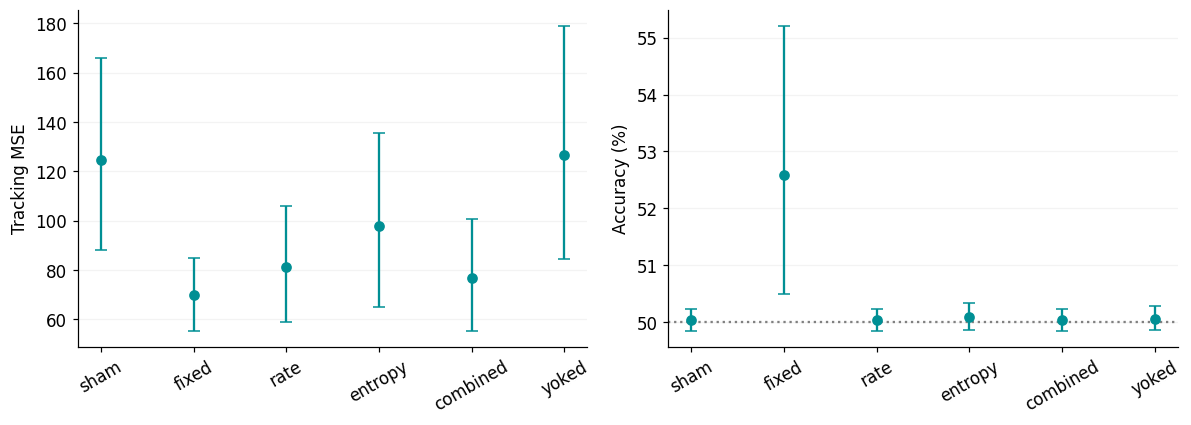

In [6]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,key,factor,label in zip(axes,['tracking_mse','accuracy'],[1,100],['Tracking MSE','Accuracy (%)']):
    for i,a in enumerate(ARMS):
        m,lo,hi=study['summary']['nominal_'+a][key]
        ax.errorbar(i,m*factor,yerr=[[factor*(m-lo)],[factor*(hi-m)]],fmt='o',capsize=4,color='#008f94')
    ax.set_xticks(range(6),ARMS,rotation=30);ax.set_ylabel(label);ax.grid(axis='y',alpha=.15)
axes[1].axhline(50,ls=':',color='gray');fig.tight_layout();plt.show()

## 6. Does the entropy term survive observation stress?

Negative differences mean lower error with combined feedback; positive differences mean higher error. The clean-measurement advantage did not restore binary task accuracy. These intervals cannot be interpreted as treatment-effect uncertainty in patients.

In [7]:
for condition in ('nominal','delay_2s','sensor_noise','stimulation_artifact','plasticity'):
    mean,lo,hi=study['contrasts'][condition+'_combined_minus_rate']['tracking_mse']
    print(f'{condition:24s} {mean:+.3f}  [{lo:+.3f}, {hi:+.3f}]')

nominal                  -4.533  [-6.543, -2.834]
delay_2s                 -0.773  [-2.997, +1.571]
sensor_noise             +8.283  [+4.604, +12.653]
stimulation_artifact     +3.523  [-0.108, +7.562]
plasticity               -4.598  [-6.510, -3.013]


## 7. Plasticity is a specified rule, not a clinical finding

Here the covariance term stops at 45 seconds and weights relax toward their starting values with a 20-second time constant. Remaining changes must not be described as demonstrated durable human rewiring.

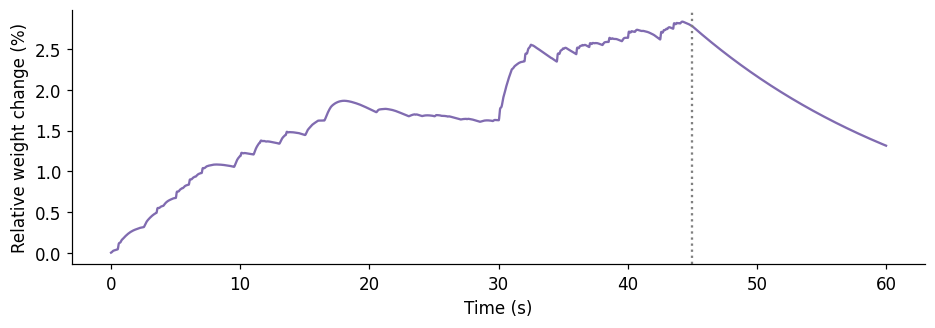

Observed washout ratio: 0.4723488381464663
Prescribed approximate ratio: 0.4723665527410147


In [8]:
plastic_run = simulate(person,'combined',seed=seed,calibration=calibration,plasticity=.15)
fig,ax=plt.subplots(figsize=(10,3));ax.plot(time,100*plastic_run['drift'],color='#806bb0');ax.axvline(45,ls=':',color='gray');ax.set(xlabel='Time (s)',ylabel='Relative weight change (%)');plt.show()
print('Observed washout ratio:',plastic_run['drift'][-1]/plastic_run['drift'][4499])
print('Prescribed approximate ratio:',np.exp(-15/20))

## 8. Minimal local checks and next experiments

The full package adds 13 verification checks, including an independent ODE solver comparison. Useful next tests include equally optimized energy-matched controllers, a realistic observation model, held-out session calibration, and empirical tasks selected with autistic participants. The current simulation does not establish that entropy is a causal mediator of benefit.

In [9]:
assert permutation_entropy(np.arange(100.)) == 0
assert 0 <= permutation_entropy(np.random.default_rng(1).normal(size=1000)) <= 1
assert abs(runs['combined']['u']).max() <= .600000001
assert np.array_equal(runs['combined']['label'],runs['sham']['label'])
print('Local estimator, input-bound and task-stream checks passed.')

Local estimator, input-bound and task-stream checks passed.


## Sources and reproducibility

The accompanying `references.bib`, evidence ledger and manuscript contain the full 22-source bibliography. Key context: [Ilioska et al., 2026](https://doi.org/10.1038/s44220-026-00656-y); [Stoliker et al., 2026](https://doi.org/10.1038/s41586-026-10910-z); [Tan et al., 2026](https://doi.org/10.1136/bmj-2025-086295). None supplies an autism-specific entropy target for this model.

The benchmark was exploratory, including pilot parameter refinement. No clinical study or preregistration is claimed. An independent human author review is required before publication.